# Value Function approximation

- Introduction
- incremental Methods
- Batch methods



## Introduction

Reinforcement learning can be used to solve large problems, e.g.
- Backgammon: $10^20$ states
- Computer Go: $10^170$ states
- Helicopter: continuous state space

How can we scale up the model-free methods for prediction and control from the last two lectures?

## Value Function Approximation

- So far we have represented value function by a *lookup table*
  - Every state $s$ has an entry $V(s)$
  - Or every state-action pair $s, a$ has an entry $Q(s, a)$
- Problem with large MDPs:
  - There are too many states and/or actions to store in memory
  - It is too slow to learn the value of each state individually
- Solution for large MDPs:
  - Estimate value function with *function approximation*

$$\hat{v}(s, \mathbf{w}) \approx v_\pi(s)$$

$$\text{or } \hat{q}(s, a, \mathbf{w}) \approx q_\pi(s, a)$$

  - *Generalise* from seen states to unseen states
  - *Update* parameter $\mathbf{w}$ using MC or TD learning

## Types of Value Function Approximators

<img src="../image-101.png" width="400px"/><div>

Three common input/output configurations:

1. **State value**: $s \rightarrow \hat{v}(s, \mathbf{w})$
   - Input: state $s$, output: one scalar

2. **Action value (one action)**: $(s, a) \rightarrow \hat{q}(s, a, \mathbf{w})$
   - Input: state + action, output: one scalar

3. **Action value (all actions)**: $s \rightarrow \hat{q}(s, a_1, \mathbf{w}), \dots, \hat{q}(s, a_m, \mathbf{w})$
   - Input: state only, output: one value **per action**
   - Most efficient for action selection (single forward pass)
   - used in Atari games

In all cases, $\mathbf{w}$ are the learned parameters of the approximator (e.g. a neural network).

There are many function approximators, e.g.
- **Linear combinations of features**
- **Neural network**
- Decision tree
- Nearest neighbour
- Fourier/wavelet based
- ...

Here focus on differentiable function approximators

Require training method suitable for non-stationary, non-iid data



## Incremental methods



### Gradient descent

- Let $J(\mathbf{w})$ be a differentiable function of parameter vector $\mathbf{w}$
- Define the *gradient* of $J(\mathbf{w})$ to be

$$\nabla_\mathbf{w} J(\mathbf{w}) = \begin{pmatrix} \frac{\partial J(\mathbf{w})}{\partial w_1} \\ \vdots \\ \frac{\partial J(\mathbf{w})}{\partial w_n} \end{pmatrix}$$

- To find a local minimum of $J(\mathbf{w})$
- Adjust $\mathbf{w}$ in direction of -ve gradient

$$\Delta\mathbf{w} = -\frac{1}{2}\alpha \nabla_\mathbf{w} J(\mathbf{w})$$

where $\alpha$ is a step-size parameter

The $\frac{1}{2}$ often appears when $J(\mathbf{w})$ is a **mean squared error** loss:

$$J(\mathbf{w}) = \frac{1}{2}\sum_i (y_i - \hat{y}_i)^2$$

where the $\frac{1}{2}$ is introduced *in the loss itself* so that it cancels cleanly with the exponent when differentiating, giving tidy update rules. The slide likely just carried that factor into the update notation. It has no effect since $\alpha$ is a free hyperparameter anyway.

### Value Function Approx. By Stochastic Gradient Descent

- Goal: find parameter vector **w** minimising mean-squared error between approximate value fn $\hat{v}(s, \mathbf{w})$ and true value fn $v_\pi(s)$, (let's imagine we have this true $v_\pi$  like an oracle)

$$J(\mathbf{w}) = \mathbb{E}_\pi\left[(v_\pi(S) - \hat{v}(S, \mathbf{w}))^2\right]$$

- Gradient descent finds a local minimum

$$\Delta\mathbf{w} = -\frac{1}{2}\alpha \nabla_\mathbf{w} J(\mathbf{w})$$
$$= \alpha \mathbb{E}_\pi\left[(v_\pi(S) - \hat{v}(S, \mathbf{w})) \nabla_\mathbf{w} \hat{v}(S, \mathbf{w})\right]$$

- Stochastic gradient descent *samples* the gradient

$$\Delta\mathbf{w} = \alpha(v_\pi(S) - \hat{v}(S, \mathbf{w}))\nabla_\mathbf{w}\hat{v}(S, \mathbf{w})$$

- Expected update is equal to full gradient update

### Feature Vectors

- Represent state by a *feature vector*

$$\mathbf{x}(S) = \begin{pmatrix} \mathbf{x}_1(S) \\ \vdots \\ \mathbf{x}_n(S) \end{pmatrix}$$

- For example:
  - Distance of robot from landmarks
  - Trends in the stock market
  - Piece and pawn configurations in chess

### Linear Value Function Approximation

- Represent value function by a linear combination of features

$$\hat{v}(S, \mathbf{w}) = \mathbf{x}(S)^\top \mathbf{w} = \sum_{j=1}^{n} \mathbf{x}_j(S)\mathbf{w}_j$$

- Objective function is quadratic in parameters **w**

$$J(\mathbf{w}) = \mathbb{E}_\pi\left[(v_\pi(S) - \mathbf{x}(S)^\top\mathbf{w})^2\right]$$

- Stochastic gradient descent converges on *global* optimum (with linear combination)
- Update rule is particularly simple

$$\nabla_\mathbf{w}\hat{v}(S, \mathbf{w}) = \mathbf{x}(S)$$
$$\Delta\mathbf{w} = \alpha(v_\pi(S) - \hat{v}(S, \mathbf{w}))\mathbf{x}(S)$$

Update $=$ *step-size* $\times$ *prediction error* $\times$ *feature value*

### Table Lookup Features

- Table lookup is a special case of linear value function approximation
- Using *table lookup features*

$$\mathbf{x}^{table}(S) = \begin{pmatrix} \mathbf{1}(S = s_1) \\ \vdots \\ \mathbf{1}(S = s_n) \end{pmatrix}$$

Each entry is an indicator: $\mathbf{1}(S = s_i) = 1$ if the current state is $s_i$, and $0$ otherwise.
So $\mathbf{x}^{table}(S)$ is a one-hot vector — exactly one entry is $1$, all others are $0$.

- Parameter vector **w** gives value of each individual state

$$\hat{v}(S, \mathbf{w}) = \begin{pmatrix} \mathbf{1}(S = s_1) \\ \vdots \\ \mathbf{1}(S = s_n) \end{pmatrix} \cdot \begin{pmatrix} \mathbf{w}_1 \\ \vdots \\ \mathbf{w}_n \end{pmatrix}$$

Since the feature vector is one-hot, the dot product simply selects $\mathbf{w}_i$ for whichever state $S = s_i$ is active.
In other words, $\hat{v}(S, \mathbf{w}) = \mathbf{w}_i$ — each weight directly stores the value of one state.

This recovers **exact tabular RL**: no generalisation across states, every state has its own independent value estimate.
Function approximation reduces to a lookup table as a degenerate special case.

### Incremental Prediction Algorithms

- So far, we have assumed true value function $v_\pi(s)$ given by supervisor
- But in RL there is no supervisor, only rewards
- In practice, we substitute a *target* for $v_\pi(s)$

The key insight: we never know $v_\pi(s)$ exactly, so we replace it with a
bootstrapped or sampled estimate depending on the algorithm.
The update rule $\Delta\mathbf{w} = \alpha(\text{target} - \hat{v}(S_t, \mathbf{w}))\nabla_\mathbf{w}\hat{v}(S_t, \mathbf{w})$
is the same in all cases — only the target differs.

---

#### Monte Carlo (MC)

Target is the actual return $G_t$:

$$\Delta\mathbf{w} = \alpha(G_t - \hat{v}(S_t, \mathbf{w}))\nabla_\mathbf{w}\hat{v}(S_t, \mathbf{w})$$

$G_t$ is the true sampled return from that episode. Unbiased but high variance —
you must wait until the episode ends to update.

---

#### TD(0)

Target is the one-step bootstrapped estimate $R_{t+1} + \gamma\hat{v}(S_{t+1}, \mathbf{w})$:

$$\Delta\mathbf{w} = \alpha(R_{t+1} + \gamma\hat{v}(S_{t+1}, \mathbf{w}) - \hat{v}(S_t, \mathbf{w}))\nabla_\mathbf{w}\hat{v}(S_t, \mathbf{w})$$

Updates online after each step. Lower variance than MC but biased because the
target itself depends on the current (imperfect) **w**.

---

#### TD($\lambda$)

Target is the $\lambda$-return $G_t^\lambda$, a geometric mixture of $n$-step returns:

$$\Delta\mathbf{w} = \alpha(G_t^\lambda - \hat{v}(S_t, \mathbf{w}))\nabla_\mathbf{w}\hat{v}(S_t, \mathbf{w})$$

$\lambda \in [0,1]$ interpolates between TD(0) ($\lambda=0$) and MC ($\lambda=1$),
trading off bias and variance. In practice implemented efficiently via eligibility traces.

### Monte-Carlo with Value Function Approximation

- Return $G_t$ is an unbiased, noisy sample of true value $v_\pi(S_t)$
- Can therefore apply supervised learning to "training data":

$$\langle S_1, G_1\rangle, \langle S_2, G_2\rangle, ..., \langle S_T, G_T\rangle$$

Each episode generates a sequence of (state, return) pairs. Since $G_t$ is an
unbiased estimate of $v_\pi(S_t)$, this is exactly like regression with noisy labels —
we can treat it as a standard supervised learning problem.

---

#### Linear Monte-Carlo Policy Evaluation

$$\Delta\mathbf{w} = \alpha(G_t - \hat{v}(S_t, \mathbf{w}))\nabla_\mathbf{w}\hat{v}(S_t, \mathbf{w})$$
$$= \alpha(G_t - \hat{v}(S_t, \mathbf{w}))\mathbf{x}(S_t)$$

The second line uses the fact that for linear approximation
$\nabla_\mathbf{w}\hat{v}(S_t, \mathbf{w}) = \mathbf{x}(S_t)$ 

The **gradient is just the feature vector**: 

$$\hat{v}(S, \mathbf{w}) = \mathbf{x}(S)^\top \mathbf{w} = \sum_{j=1}^n x_j(S) w_j$$

Taking the gradient with respect to $\mathbf{w}$:

$$\frac{\partial \hat{v}}{\partial w_j} = x_j(S)$$

So:

$$\nabla_\mathbf{w}\hat{v}(S, \mathbf{w}) = \mathbf{x}(S)$$

The features $\mathbf{x}(S)$ don't depend on $\mathbf{w}$ — they're fixed functions of the state.
The weights $\mathbf{w}$ appear linearly, so differentiating just peels them off,
leaving the feature vector. Same reason $\frac{d}{dw}(aw) = a$.



The update has a clean interpretation:
- $(G_t - \hat{v}(S_t, \mathbf{w}))$ is the **prediction error** — how wrong our estimate was
- $\mathbf{x}(S_t)$ is the **feature vector** — which dimensions of **w** to adjust
- $\alpha$ controls the **step size**

Each weight $w_j$ is nudged proportionally to both the error and the feature $x_j(S_t)$.

---

- Monte-Carlo evaluation converges to a **local optimum**
- Even when using non-linear value function approximation

> Note: convergence to a *local* (not global) optimum is guaranteed for non-linear
> approximators. For linear approximation, the objective is quadratic so SGD finds
> the global optimum.

### TD Learning with Value Function Approximation

- The TD-target $R_{t+1} + \gamma\hat{v}(S_{t+1}, \mathbf{w})$ is a *biased* sample of true value $v_\pi(S_t)$
- Can still apply supervised learning to "training data":

$$\langle S_1, R_2 + \gamma\hat{v}(S_2, \mathbf{w})\rangle, \langle S_2, R_3 + \gamma\hat{v}(S_3, \mathbf{w})\rangle, ..., \langle S_{T-1}, R_T\rangle$$

Unlike MC, the target is not the true return but a **bootstrap estimate** — it uses the
current approximation $\hat{v}$ to estimate future value. This introduces bias because
the target itself depends on the parameters **w** being learned. Despite this, TD still works.

---

#### Linear TD(0)

$$\Delta\mathbf{w} = \alpha(R + \gamma\hat{v}(S', \mathbf{w}) - \hat{v}(S, \mathbf{w}))\nabla_\mathbf{w}\hat{v}(S, \mathbf{w})$$
$$= \alpha\delta\mathbf{x}(S)$$

Where $\delta = R + \gamma\hat{v}(S', \mathbf{w}) - \hat{v}(S, \mathbf{w})$ is the **TD error** — the difference
between the bootstrapped target and the current estimate.

Again, $\nabla_\mathbf{w}\hat{v}(S, \mathbf{w}) = \mathbf{x}(S)$ for linear approximation, so the update
simplifies to: scale the feature vector by the TD error and step size.

> Note: we do **not** differentiate through the TD target $R + \gamma\hat{v}(S', \mathbf{w})$ —
> it is treated as a fixed constant when computing the gradient. This is what makes
> TD a *semi-gradient* method.

---

- Linear TD(0) converges **(close)** to global optimum

> "Close" because TD does not minimise the MSE directly — it converges to the
> **TD fixed point**, which is near but not identical to the true least-squares solution.
> The error at the TD fixed point is bounded by a factor of $\frac{1}{1-\gamma}$ times
> the minimum possible MSE.

### TD(λ) with Value Function Approximation

- The $\lambda$-return $G_t^\lambda$ is also a biased sample of true value $v_\pi(s)$
- Can again apply supervised learning to "training data":

$$\left\langle S_1, G_1^\lambda\right\rangle, \left\langle S_2, G_2^\lambda\right\rangle, ..., \left\langle S_{T-1}, G_{T-1}^\lambda\right\rangle$$

---

#### Forward View Linear TD(λ)

$$\Delta\mathbf{w} = \alpha(G_t^\lambda - \hat{v}(S_t, \mathbf{w}))\nabla_\mathbf{w}\hat{v}(S_t, \mathbf{w})$$
$$= \alpha(G_t^\lambda - \hat{v}(S_t, \mathbf{w}))\mathbf{x}(S_t)$$

The $\lambda$-return $G_t^\lambda$ is a weighted average of all $n$-step returns:
- $\lambda=0$: reduces to TD(0), full bootstrap
- $\lambda=1$: reduces to MC, no bootstrap

The forward view looks **ahead** to future rewards to compute $G_t^\lambda$,
so it requires the full episode before updating — not practical online.

---

#### Backward View Linear TD(λ)

$$\delta_t = R_{t+1} + \gamma\hat{v}(S_{t+1}, \mathbf{w}) - \hat{v}(S_t, \mathbf{w})$$
$$E_t = \gamma\lambda E_{t-1} + \mathbf{x}(S_t)$$
$$\Delta\mathbf{w} = \alpha\delta_t E_t$$

The backward view is the **online, implementable equivalent** of the forward view.

- $\delta_t$ is the one-step **TD error** at time $t$
- $E_t$ is the **eligibility trace** — a memory vec

### Control with value function approximation

<img src="../image-102.png" width="400px">

- Policy evaluation: Approximate policy evaluation, $\hat{q}(\cdot, \cdot, \mathbf{w}) \approx q_\pi$
- Policy improvement: $\epsilon$-greedy policy improvement

### Action-Value Function Approximation

- Approximate the action-value function

$$\hat{q}(S, A, \mathbf{w}) \approx q_\pi(S, A)$$

Same idea as value function approximation, but now we approximate $q(S, A)$
over both state **and** action — needed for control (policy improvement requires
comparing action values).

---

#### Objective

Minimise mean-squared error between approximate action-value fn $\hat{q}(S, A, \mathbf{w})$
and true action-value fn $q_\pi(S, A)$:

$$J(\mathbf{w}) = \mathbb{E}_\pi\left[(q_\pi(S, A) - \hat{q}(S, A, \mathbf{w}))^2\right]$$

---

#### Stochastic Gradient Descent

$$-\frac{1}{2}\nabla_\mathbf{w}J(\mathbf{w}) = (q_\pi(S, A) - \hat{q}(S, A, \mathbf{w}))\nabla_\mathbf{w}\hat{q}(S, A, \mathbf{w})$$

$$\Delta\mathbf{w} = \alpha(q_\pi(S, A) - \hat{q}(S, A, \mathbf{w}))\nabla_\mathbf{w}\hat{q}(S, A, \mathbf{w})$$

Identical in structure to value function approximation. The update:
- moves **w** to reduce the error between target $q_\pi(S,A)$ and prediction $\hat{q}(S,A,\mathbf{w})$
- scales the step by the gradient of $\hat{q}$ w.r.t. **w**

In practice, $q_\pi(S, A)$ is unknown and replaced by a target:
- **MC**: $G_t$
- **TD(0)**: $R_{t+1} + \gamma \hat{q}(S_{t+1}, A_{t+1}, \mathbf{w})$
- **TD(λ)**: $q_t^\lambda$

### Linear Action-Value Function Approximation

- Represent state *and* action by a *feature vector*

$$\mathbf{x}(S, A) = \begin{pmatrix} \mathbf{x}_1(S, A) \\ \vdots \\ \mathbf{x}_n(S, A) \end{pmatrix}$$

Each feature $\mathbf{x}_j(S, A)$ captures some aspect of the (state, action) pair —
e.g. distance to goal combined with action direction, or tile coding over state-action space.

---

#### Linear Action-Value Function

$$\hat{q}(S, A, \mathbf{w}) = \mathbf{x}(S, A)^\top \mathbf{w} = \sum_{j=1}^{n} \mathbf{x}_j(S, A)\mathbf{w}_j$$

The action-value is a weighted sum of features. Each weight $w_j$ captures
how much feature $j$ contributes to the value of taking action $A$ in state $S$.

---

#### Stochastic Gradient Descent Update

$$\nabla_\mathbf{w}\hat{q}(S, A, \mathbf{w}) = \mathbf{x}(S, A)$$

$$\Delta\mathbf{w} = \alpha(q_\pi(S, A) - \hat{q}(S, A, \mathbf{w}))\mathbf{x}(S, A)$$

As with linear value approximation, the gradient simplifies to the feature vector
since **w** appears linearly. The update rule is:

- $(q_\pi(S,A) - \hat{q}(S,A,\mathbf{w}))$: **prediction error** for this (state, action) pair
- $\mathbf{x}(S, A)$: **feature vector** indicating which weights to adjust
- $\alpha$: **step size**

In practice $q_\pi(S,A)$ is substituted with a TD or MC target, exactly as in the
value function case.

### Incremental Control Algorithms

Like prediction, we must substitute a *target* for $q_\pi(S, A)$.
The structure is identical to the prediction case — only the target changes.

---

#### Monte Carlo

Target is the actual return $G_t$:

$$\Delta\mathbf{w} = \alpha(G_t - \hat{q}(S_t, A_t, \mathbf{w}))\nabla_\mathbf{w}\hat{q}(S_t, A_t, \mathbf{w})$$

Unbiased but high variance. Must wait until episode end to update.

---

#### TD(0)

Target is the one-step bootstrap $R_{t+1} + \gamma\hat{q}(S_{t+1}, A_{t+1}, \mathbf{w})$:

$$\Delta\mathbf{w} = \alpha(R_{t+1} + \gamma\hat{q}(S_{t+1}, A_{t+1}, \mathbf{w}) - \hat{q}(S_t, A_t, \mathbf{w}))\nabla_\mathbf{w}\hat{q}(S_t, A_t, \mathbf{w})$$

This is **Sarsa with function approximation** — the next action $A_{t+1}$ is drawn
from the current policy (on-policy). Lower variance than MC but biased since the
target depends on **w**.

---

#### Forward-View TD(λ)

Target is the action-value $\lambda$-return $q_t^\lambda$:

$$\Delta\mathbf{w} = \alpha(q_t^\lambda - \hat{q}(S_t, A_t, \mathbf{w}))\nabla_\mathbf{w}\hat{q}(S_t, A_t, \mathbf{w})$$

$q_t^\lambda$ blends $n$-step returns with geometric weights $(1-\lambda)\lambda^{n-1}$.
Requires full episode — not practical online.

---

#### Backward-View TD(λ)

$$\delta_t = R_{t+1} + \gamma\hat{q}(S_{t+1}, A_{t+1}, \mathbf{w}) - \hat{q}(S_t, A_t, \mathbf{w})$$
$$E_t = \gamma\lambda E_{t-1} + \nabla_\mathbf{w}\hat{q}(S_t, A_t, \mathbf{w})$$
$$\Delta\mathbf{w} = \alpha\delta_t E_t$$

The online equivalent of forward-view TD(λ):
- $\delta_t$: **TD error** — how wrong the current prediction was
- $E_t$: **eligibility trace** — accumulates gradients of visited (state, action) pairs,
  decaying by $\gamma\lambda$ each step. Assigns credit to recently visited pairs.
- Update all weights at every step, weighted by their trace

> For linear approximation, $\nabla_\mathbf{w}\hat{q}(S_t, A_t, \mathbf{w}) = \mathbf{x}(S_t, A_t)$,
> so the trace simply accumulates feature vectors: $E_t = \gamma\lambda E_{t-1} + \mathbf{x}(S_t, A_t)$.

### Mountain Car — Semi-gradient TD(0) with Linear Function Approximation

We now apply the theory above to a concrete problem: **Mountain Car** from Gymnasium.

**Environment:**
- A car is stuck in a valley between two hills
- Goal: drive up the right hill (position ≥ 0.5)
- The car's engine is too weak to climb directly — it must build momentum by rocking back and forth
- **State**: (position, velocity) — continuous, 2D
- **Actions**: 0 = push left, 1 = no push, 2 = push right
- **Reward**: −1 per time step (episode truncates at 200 steps)

**Algorithm:** Semi-gradient **Sarsa** (TD(0) for control) with **tile coding** features.

We use **tile coding** to create binary feature vectors from continuous states. Each tile is a binary indicator — either the state falls in that tile (1) or it doesn't (0). Multiple overlapping tilings provide generalisation: nearby states share tiles and thus share weight updates.

#### Update rule (Semi-gradient Sarsa)

$$\mathbf{w} \leftarrow \mathbf{w} + \alpha\left[R_{t+1} + \gamma\hat{q}(S_{t+1}, A_{t+1}, \mathbf{w}) - \hat{q}(S_t, A_t, \mathbf{w})\right]\nabla_\mathbf{w}\hat{q}(S_t, A_t, \mathbf{w})$$

With linear function approximation and tile coding:
- $\hat{q}(S, A, \mathbf{w}) = \mathbf{x}(S, A)^\top\mathbf{w}$
- $\nabla_\mathbf{w}\hat{q}(S, A, \mathbf{w}) = \mathbf{x}(S, A)$ (the active tile indices)
- The update simplifies to incrementing only the weights of **active tiles**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

%matplotlib inline

### Tile Coding

Tile coding converts a continuous state into a sparse binary feature vector. We overlay
**num_tilings** grids over the state space, each offset slightly from the others.

For each tiling, the state falls in exactly one tile → one active feature per tiling.
With `num_tilings` tilings and 3 actions, the feature vector $\mathbf{x}(S, A)$ has
`num_tilings` active (= 1) entries out of `num_tilings × tiles_per_tiling × num_actions` total.

The offsets ensure that nearby states share some (but not all) tiles, enabling
**generalisation**: updating the value of one state also nudges the values of
neighbouring states.

In [5]:
class TileCoder:
    """Tile coding for 2D continuous states (position, velocity) × discrete actions."""

    def __init__(self, num_tilings=8, num_tiles_per_dim=8, num_actions=3,
                 state_low=np.array([-1.2, -0.07]),
                 state_high=np.array([0.6, 0.07])):
        self.num_tilings = num_tilings
        self.num_tiles_per_dim = num_tiles_per_dim
        self.num_actions = num_actions

        # Total number of features (weights)
        self.total_tiles = num_tilings * num_tiles_per_dim**2 * num_actions

        # Scale state from [low, high] to [0, num_tiles_per_dim) range
        self.state_low = state_low
        self.state_scale = num_tiles_per_dim / (state_high - state_low)

        # Offsets for each tiling — uniformly spaced within one tile width
        self.offsets = np.array([
            (np.array([i, i * 3]) / num_tilings) for i in range(num_tilings)
        ])

    def get_active_tiles(self, state, action):
        """Return indices of active tiles for (state, action) pair."""
        # Shift state so that state_low maps to 0, then scale
        scaled = (state - self.state_low) * self.state_scale
        active = np.zeros(self.num_tilings, dtype=int)

        for tiling in range(self.num_tilings):
            shifted = scaled + self.offsets[tiling]
            # Clamp tile indices to valid range
            pos_tile = int(np.clip(np.floor(shifted[0]), 0, self.num_tiles_per_dim - 1))
            vel_tile = int(np.clip(np.floor(shifted[1]), 0, self.num_tiles_per_dim - 1))
            # Unique index: tiling offset + position + velocity + action
            tile_idx = (tiling * self.num_tiles_per_dim**2 * self.num_actions
                        + (pos_tile * self.num_tiles_per_dim + vel_tile) * self.num_actions
                        + action)
            active[tiling] = tile_idx

        return active


# Quick check
tc = TileCoder()
print(f"Total number of weights: {tc.total_tiles}")
print(f"Active tiles for state=(-0.5, 0.0), action=2: {tc.get_active_tiles(np.array([-0.5, 0.0]), 2)}")

# Verify different states give different tiles
t1 = tc.get_active_tiles(np.array([-0.5, 0.0]), 0)
t2 = tc.get_active_tiles(np.array([0.0, 0.0]), 0)
print(f"Tiles for (-0.5, 0.0): {t1}")
print(f"Tiles for ( 0.0, 0.0): {t2}")
print(f"Overlap: {len(set(t1) & set(t2))} tiles")

Total number of weights: 1536
Active tiles for state=(-0.5, 0.0), action=2: [  86  278  470  665  857 1049 1244 1436]
Tiles for (-0.5, 0.0): [  84  276  468  663  855 1047 1242 1434]
Tiles for ( 0.0, 0.0): [ 132  324  516  711  903 1095 1314 1506]
Overlap: 0 tiles


### Semi-gradient Sarsa (TD(0) Control) Agent

The agent maintains a weight vector $\mathbf{w}$ and uses tile coding features.

**Value estimation:** $\hat{q}(S, A, \mathbf{w}) = \sum_{i \in \text{active tiles}} w_i$

Since tile coding features are binary (0 or 1), the dot product $\mathbf{x}(S,A)^\top\mathbf{w}$ is simply the sum of weights at active tile indices.

**Update:** For active tile indices $\mathcal{A}$:

$$w_i \leftarrow w_i + \frac{\alpha}{|\text{num\_tilings}|}\delta, \quad \forall i \in \mathcal{A}$$

where $\delta = R_{t+1} + \gamma\hat{q}(S_{t+1}, A_{t+1}, \mathbf{w}) - \hat{q}(S_t, A_t, \mathbf{w})$

We divide $\alpha$ by `num_tilings` because each state activates `num_tilings` tiles — without this, the effective step size would be `num_tilings × α`.

In [6]:
class SemiGradientSarsa:
    """Semi-gradient Sarsa with linear function approximation (tile coding)."""

    def __init__(self, tile_coder, alpha=0.1, gamma=1.0, epsilon=0.1):
        self.tc = tile_coder
        self.alpha = alpha / tile_coder.num_tilings  # normalize step size
        self.gamma = gamma
        self.epsilon = epsilon
        self.w = np.zeros(tile_coder.total_tiles)

    def q_hat(self, state, action):
        """Estimated action-value: sum of weights at active tiles."""
        tiles = self.tc.get_active_tiles(state, action)
        return np.sum(self.w[tiles])

    def select_action(self, state):
        """ε-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.tc.num_actions)
        # Greedy: pick action with highest q_hat
        q_values = [self.q_hat(state, a) for a in range(self.tc.num_actions)]
        return int(np.argmax(q_values))

    def update(self, state, action, reward, next_state, next_action, done):
        """Semi-gradient Sarsa update."""
        active_tiles = self.tc.get_active_tiles(state, action)
        q_current = np.sum(self.w[active_tiles])

        if done:
            td_target = reward
        else:
            q_next = np.sum(self.w[self.tc.get_active_tiles(next_state, next_action)])
            td_target = reward + self.gamma * q_next

        td_error = td_target - q_current
        self.w[active_tiles] += self.alpha * td_error

### Training Loop

We train for several episodes. In each episode:
1. Reset environment, select initial action (ε-greedy)
2. Loop: take action → observe reward, next state → select next action → update weights
3. Record steps per episode (fewer steps = better policy, since reward = −1 per step)

In [8]:
def train(num_episodes=500, alpha=0.5, gamma=1.0, epsilon=0.0,
          num_tilings=8, num_tiles_per_dim=8):
    """Train semi-gradient Sarsa on Mountain Car.

    Note: gamma=1.0 because Mountain Car is an undiscounted episodic task —
    we want to minimise total steps (each step gives reward = -1).
    epsilon=0 works because weights are initialised to 0 (optimistic: true values
    are all negative), which drives sufficient exploration without explicit ε-greedy.
    """
    env = gym.make("MountainCar-v0")
    tc = TileCoder(num_tilings=num_tilings, num_tiles_per_dim=num_tiles_per_dim)
    agent = SemiGradientSarsa(tc, alpha=alpha, gamma=gamma, epsilon=epsilon)

    steps_per_episode = np.zeros(num_episodes)

    for ep in range(num_episodes):
        state, _ = env.reset()
        action = agent.select_action(state)
        steps = 0

        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1

            if done:
                agent.update(state, action, reward, next_state, None, done=True)
                break

            next_action = agent.select_action(next_state)
            agent.update(state, action, reward, next_state, next_action, done=False)
            state = next_state
            action = next_action

        steps_per_episode[ep] = steps
        if (ep + 1) % 100 == 0:
            avg = np.mean(steps_per_episode[max(0, ep-99):ep+1])
            print(f"Episode {ep+1:4d} | Steps: {steps:4d} | Avg(last 100): {avg:.1f}")

    env.close()
    return agent, steps_per_episode


agent, steps_per_episode = train(num_episodes=500, alpha=0.5)

Episode  100 | Steps:  189 | Avg(last 100): 180.8
Episode  200 | Steps:  151 | Avg(last 100): 148.1
Episode  300 | Steps:  149 | Avg(last 100): 145.9
Episode  400 | Steps:  136 | Avg(last 100): 139.5
Episode  500 | Steps:  114 | Avg(last 100): 128.2


### Learning Curve

Steps per episode should decrease over time as the agent learns to reach the goal faster.
The dotted line at 200 marks the episode truncation limit — an untrained agent
never reaches the goal and always hits this ceiling.

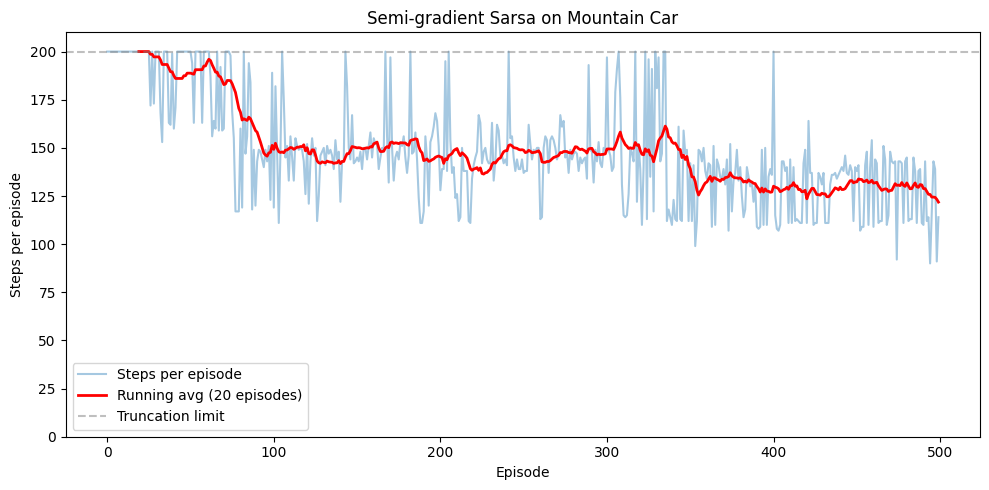

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps_per_episode, alpha=0.4, label="Steps per episode")
# Running average
window = 20
running_avg = np.convolve(steps_per_episode, np.ones(window)/window, mode="valid")
ax.plot(np.arange(window-1, len(steps_per_episode)), running_avg, color="red",
        linewidth=2, label=f"Running avg ({window} episodes)")
ax.axhline(200, color="gray", linestyle="--", alpha=0.5, label="Truncation limit")
ax.set_xlabel("Episode")
ax.set_ylabel("Steps per episode")
ax.set_title("Semi-gradient Sarsa on Mountain Car")
ax.legend()
ax.set_ylim(0, 210)
plt.tight_layout()
plt.show()

### Learned Value Function (Cost-to-go)

We plot $-\max_a \hat{q}(s, a, \mathbf{w})$ over the state space — this is the **cost-to-go** 
(negated max Q-value). It shows how many steps the agent expects to need from each state.

The valley (low position, near-zero velocity) should have the highest cost, while 
states near the goal (position ≈ 0.5) should have low cost.

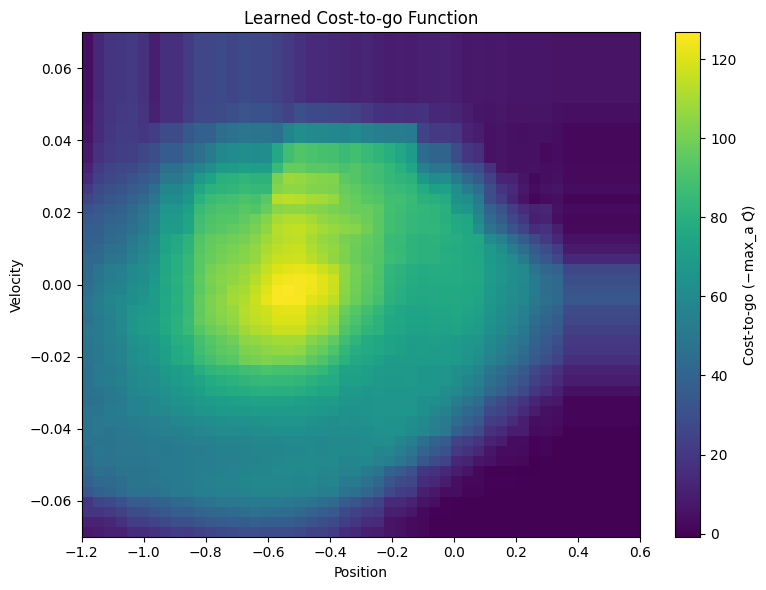

In [10]:
def plot_cost_to_go(agent, title="Learned Cost-to-go Function"):
    """Plot -max_a q_hat(s, a) over the state space."""
    positions = np.linspace(-1.2, 0.6, 50)
    velocities = np.linspace(-0.07, 0.07, 50)
    cost = np.zeros((len(velocities), len(positions)))

    for i, vel in enumerate(velocities):
        for j, pos in enumerate(positions):
            state = np.array([pos, vel])
            q_vals = [agent.q_hat(state, a) for a in range(agent.tc.num_actions)]
            cost[i, j] = -np.max(q_vals)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cost, extent=[-1.2, 0.6, -0.07, 0.07],
                   aspect="auto", origin="lower", cmap="viridis")
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="Cost-to-go (−max_a Q̂)")
    plt.tight_layout()
    plt.show()


plot_cost_to_go(agent)

### Learned Policy

The policy map shows which action the agent prefers in each region of state space:
- **0 (left)**: push left — used to build momentum when moving right won't help
- **1 (neutral)**: coasting
- **2 (right)**: push right — used when the car has enough momentum to climb

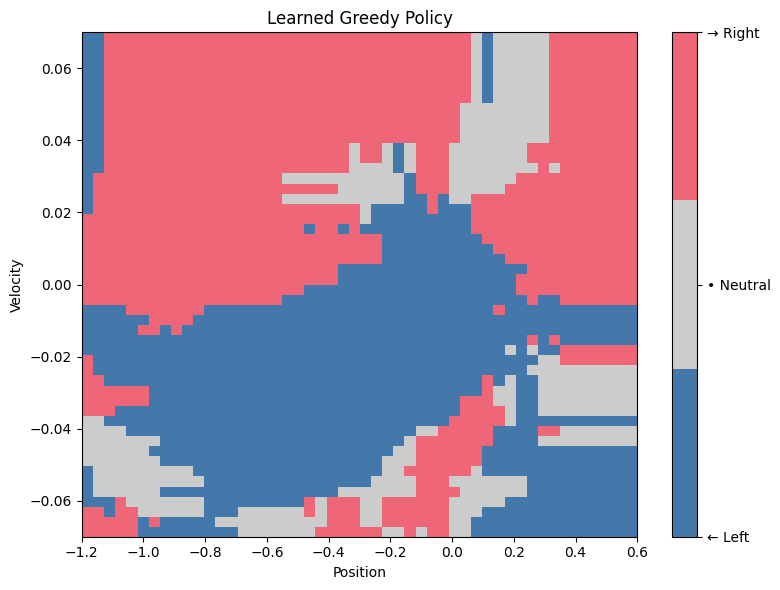

In [11]:
def plot_policy(agent):
    """Plot greedy policy over the state space."""
    positions = np.linspace(-1.2, 0.6, 50)
    velocities = np.linspace(-0.07, 0.07, 50)
    policy = np.zeros((len(velocities), len(positions)))
    action_labels = ["← Left", "• Neutral", "→ Right"]

    for i, vel in enumerate(velocities):
        for j, pos in enumerate(positions):
            state = np.array([pos, vel])
            q_vals = [agent.q_hat(state, a) for a in range(agent.tc.num_actions)]
            policy[i, j] = np.argmax(q_vals)

    fig, ax = plt.subplots(figsize=(8, 6))
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(["#4477AA", "#CCCCCC", "#EE6677"])
    im = ax.imshow(policy, extent=[-1.2, 0.6, -0.07, 0.07],
                   aspect="auto", origin="lower", cmap=cmap, vmin=0, vmax=2)
    cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(action_labels)
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_title("Learned Greedy Policy")
    plt.tight_layout()
    plt.show()


plot_policy(agent)

### Demo: Watch the Learned Agent

Run a single greedy episode (ε = 0) and plot the car's trajectory.

Episode finished in 111 steps (goal reached: True)


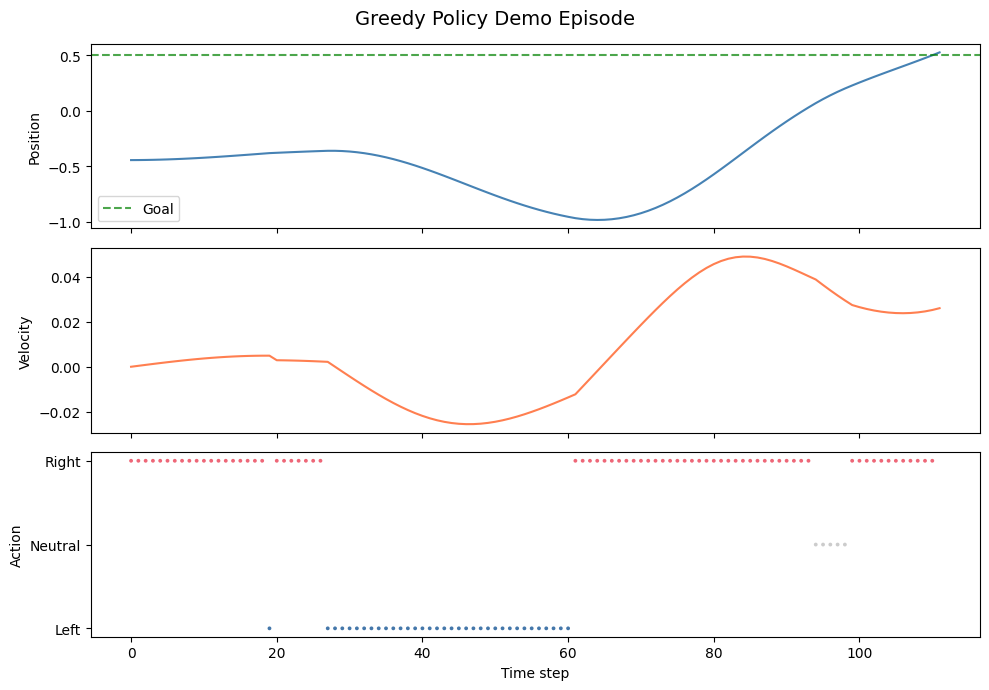

In [12]:
def run_demo(agent):
    """Run one greedy episode and plot the trajectory."""
    env = gym.make("MountainCar-v0")
    state, _ = env.reset(seed=42)

    positions, velocities, actions = [state[0]], [state[1]], []
    done = False

    while not done:
        action = agent.select_action(state)
        actions.append(action)
        state, _, terminated, truncated, _ = env.step(action)
        positions.append(state[0])
        velocities.append(state[1])
        done = terminated or truncated

    env.close()
    print(f"Episode finished in {len(actions)} steps (goal reached: {positions[-1] >= 0.5})")

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(positions, color="steelblue")
    axes[0].axhline(0.5, color="green", linestyle="--", alpha=0.7, label="Goal")
    axes[0].set_ylabel("Position")
    axes[0].legend()

    axes[1].plot(velocities, color="coral")
    axes[1].set_ylabel("Velocity")

    action_colors = {0: "#4477AA", 1: "#CCCCCC", 2: "#EE6677"}
    colors = [action_colors[a] for a in actions]
    axes[2].scatter(range(len(actions)), actions, c=colors, s=3)
    axes[2].set_yticks([0, 1, 2])
    axes[2].set_yticklabels(["Left", "Neutral", "Right"])
    axes[2].set_ylabel("Action")
    axes[2].set_xlabel("Time step")

    fig.suptitle("Greedy Policy Demo Episode", fontsize=14)
    plt.tight_layout()
    plt.show()


# Temporarily set epsilon to 0 for greedy behavior
old_eps = agent.epsilon
agent.epsilon = 0.0
run_demo(agent)
agent.epsilon = old_eps

### Effect of Step Size $\alpha$

The step size significantly affects learning speed and stability:
- **Too small** ($\alpha = 0.1$): slow convergence, needs many episodes
- **Good** ($\alpha = 0.5$): fast convergence to a good policy
- **Too large** ($\alpha = 2.0$): can diverge or oscillate (semi-gradient methods lack convergence guarantees for large $\alpha$)


Training with α = 0.1
Episode  100 | Steps:  200 | Avg(last 100): 199.8
Episode  200 | Steps:  151 | Avg(last 100): 192.3
Episode  300 | Steps:  200 | Avg(last 100): 172.6
Episode  400 | Steps:  155 | Avg(last 100): 153.7
Episode  500 | Steps:  143 | Avg(last 100): 150.8

Training with α = 0.3
Episode  100 | Steps:  187 | Avg(last 100): 192.4
Episode  200 | Steps:  147 | Avg(last 100): 155.6
Episode  300 | Steps:  149 | Avg(last 100): 147.2
Episode  400 | Steps:  147 | Avg(last 100): 148.9
Episode  500 | Steps:  147 | Avg(last 100): 130.8

Training with α = 0.5
Episode  100 | Steps:  197 | Avg(last 100): 172.7
Episode  200 | Steps:  140 | Avg(last 100): 149.1
Episode  300 | Steps:  135 | Avg(last 100): 138.8
Episode  400 | Steps:  137 | Avg(last 100): 127.7
Episode  500 | Steps:   94 | Avg(last 100): 131.6

Training with α = 1.0
Episode  100 | Steps:  149 | Avg(last 100): 174.4
Episode  200 | Steps:  121 | Avg(last 100): 141.8
Episode  300 | Steps:  143 | Avg(last 100): 145.2
Episode 

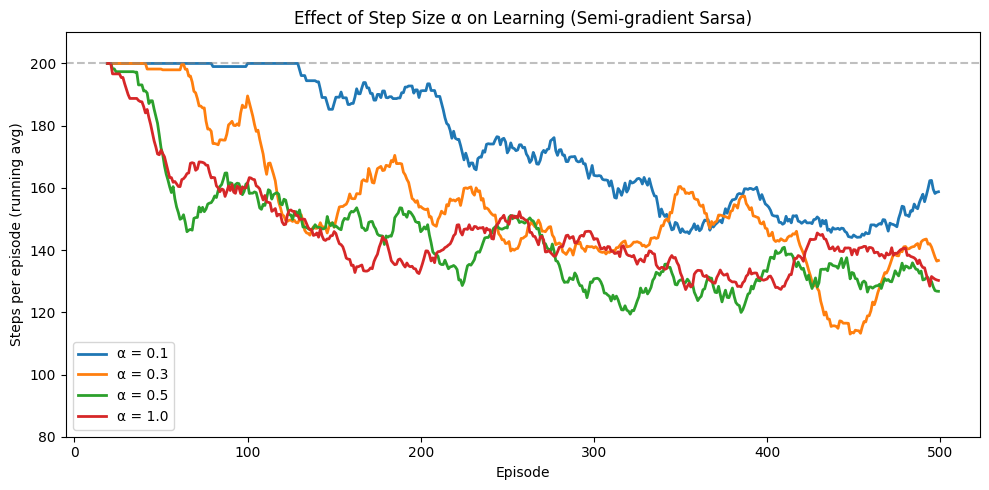

In [13]:
alphas = [0.1, 0.3, 0.5, 1.0]
results = {}
for alpha in alphas:
    print(f"\nTraining with α = {alpha}")
    _, steps = train(num_episodes=500, alpha=alpha)
    results[alpha] = steps

fig, ax = plt.subplots(figsize=(10, 5))
window = 20
for alpha, steps in results.items():
    running_avg = np.convolve(steps, np.ones(window)/window, mode="valid")
    ax.plot(np.arange(window-1, len(steps)), running_avg, label=f"α = {alpha}", linewidth=2)

ax.axhline(200, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Episode")
ax.set_ylabel("Steps per episode (running avg)")
ax.set_title("Effect of Step Size α on Learning (Semi-gradient Sarsa)")
ax.legend()
ax.set_ylim(80, 210)
plt.tight_layout()
plt.show()

### Play the Game with the Learned Policy

Render the Mountain Car environment frame-by-frame using the greedy learned policy.

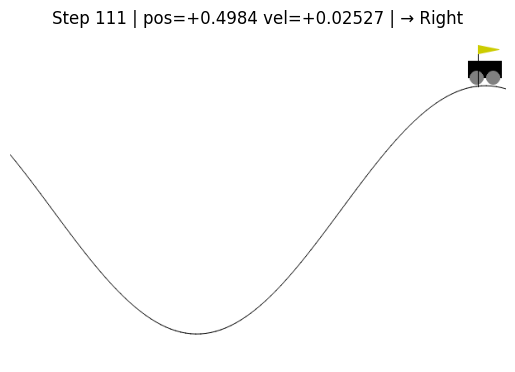

Episode finished in 111 steps (goal reached: True)


In [16]:
from IPython.display import clear_output

env = gym.make("MountainCar-v0", render_mode="rgb_array")
state, _ = env.reset(seed=42)

done = False
old_eps = agent.epsilon
agent.epsilon = 0.0
steps = 0

action_names = {0: "← Left", 1: "• Neutral", 2: "→ Right"}

while not done:
    action = agent.select_action(state)
    pos, vel = state
    print(f"Step {steps+1:3d} | pos={pos:+.4f}, vel={vel:+.5f} | action: {action_names[action]}")
    state, _, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    steps += 1

    clear_output(wait=True)
    plt.imshow(env.render())
    plt.axis("off")
    plt.title(f"Step {steps} | pos={pos:+.4f} vel={vel:+.5f} | {action_names[action]}")
    plt.show()

agent.epsilon = old_eps
env.close()
print(f"Episode finished in {steps} steps (goal reached: {state[0] >= 0.5})")

### Gradient Temporal-Difference Learning

- TD does not follow the gradient of *any* objective function
- This is why TD can diverge when off-policy or using non-linear function approximation
- **Gradient TD** follows true gradient of projected Bellman error

| On/Off-Policy | Algorithm   | Table Lookup | Linear | Non-Linear |
|---------------|-------------|:------------:|:------:|:----------:|
| On-Policy     | MC          | ✓            | ✓      | ✓          |
|               | TD          | ✓            | ✓      | ✗          |
|               | Gradient TD | ✓            | ✓      | ✓          |
| Off-Policy    | MC          | ✓            | ✓      | ✓          |
|               | TD          | ✓            | ✗      | ✗          |
|               | Gradient TD | ✓            | ✓      | ✓          |


#### The problem with TD

TD updates are not gradient descent on any loss function — they are a "semi-gradient"
(they ignore how the bootstrap target depends on the weights).
This makes TD unstable in two cases:

- Off-policy training
- Non-linear function approximation (e.g. neural nets)

#### What Gradient TD does

It minimizes the **Projected Bellman Error (PBE)** using the *true* gradient,
including the terms TD ignores.
This guarantees convergence even off-policy with non-linear approximators.

#### The cost

Two parameter vectors to maintain instead of one → roughly 2× the computation.
Main algorithms: GTD2, TDC (TD with Gradient Correction).

#### One-line summary

> TD cuts corners on the gradient and sometimes diverges.
> Gradient TD does it properly and always converges.

## Batch methods


### Batch Reinforcement Learning

- Gradient descent is simple and appealing
- But it is *not* sample efficient
- Batch methods seek to find the best fitting value function
- Given the agent's experience ("training data")

----

Online TD/gradient descent updates weights after **each** transition and then discards it.
This is wasteful — one data point, one update, thrown away.

Batch methods instead **collect experience first**, then repeatedly train on the
whole dataset until the best possible value function is found.

More updates per sample → much better sample efficiency.

> Think of it as the difference between learning from each flashcard once (online)
> vs. repeatedly reviewing your full set of notes (batch).

### Least Squares Prediction

- Given value function approximation $\hat{v}(s, \mathbf{w}) \approx v_\pi(s)$
- And experience $\mathcal{D}$ consisting of $\langle state, value \rangle$ pairs

$$\mathcal{D} = \{\langle s_1, v_1^\pi \rangle, \langle s_2, v_2^\pi \rangle, ..., \langle s_T, v_T^\pi \rangle\}$$

- Which parameters $\mathbf{w}$ give the *best fitting* value fn $\hat{v}(s, \mathbf{w})$?
- Least squares algorithms find parameter vector $\mathbf{w}$ minimising
  sum-squared error between $\hat{v}(s_t, \mathbf{w})$ and target values $v_t^\pi$:

$$LS(\mathbf{w}) = \sum_{t=1}^{T} (v_t^\pi - \hat{v}(s_t, \mathbf{w}))^2
= \mathbb{E}_\mathcal{D}\left[(v^\pi - \hat{v}(s, \mathbf{w}))^2\right]$$

#### Simple explanation

We have a dataset of visited states and their true values.
We want to find weights **w** so that our approximator $\hat{v}(s, \mathbf{w})$
matches those true values as closely as possible.

The loss $LS(\mathbf{w})$ is just **mean squared error** — the same objective
as supervised regression. Least squares solves for the **w** that minimises it
directly, without iterative gradient steps.

> Instead of nudging **w** one sample at a time (TD/gradient descent),
> least squares finds the optimal **w** in one shot from the full batch.

## Stochastic Gradient Descent with Experience Replay

Given experience consisting of $\langle state, value \rangle$ pairs

$$\mathcal{D} = \{\langle s_1, v_1^\pi \rangle, \langle s_2, v_2^\pi \rangle, ..., \langle s_T, v_T^\pi \rangle\}$$

Repeat:

1. Sample state, value from experience

$$\langle s, v^\pi \rangle \sim \mathcal{D}$$

2. Apply stochastic gradient descent update

$$\Delta\mathbf{w} = \alpha(v^\pi - \hat{v}(s, \mathbf{w}))\nabla_\mathbf{w}\hat{v}(s, \mathbf{w})$$

Converges to least squares solution

$$\mathbf{w}^\pi = \underset{\mathbf{w}}{\argmin} \ LS(\mathbf{w})$$

### Simple explanation

Instead of using each experience once and discarding it (online TD),
experience replay **stores all past transitions** and randomly samples from them
to perform gradient updates.

**Why random sampling matters:** consecutive experiences are highly correlated.
Training on them in order causes the model to overfit recent transitions.
Random sampling **breaks these correlations**, stabilising learning.

**The update** is standard SGD on MSE — move **w** in the direction that
reduces the error between the prediction $\hat{v}(s, \mathbf{w})$ and the target $v^\pi$.

> This is the core trick behind **DQN**: store transitions in a replay buffer,
> sample mini-batches randomly, apply gradient updates — simple but very effective.

## Experience Replay in Deep Q-Networks (DQN)

DQN uses **experience replay** and **fixed Q-targets**

- Take action $a_t$ according to $\epsilon$-greedy policy
- Store transition $(s_t, a_t, r_{t+1}, s_{t+1})$ in replay memory $\mathcal{D}$
- Sample random mini-batch of transitions $(s, a, r, s')$ from $\mathcal{D}$
- Compute Q-learning targets w.r.t. old, fixed parameters $w^-$
- Optimise MSE between Q-network and Q-learning targets

$$\mathcal{L}_i(w_i) = \mathbb{E}_{s,a,r,s' \sim \mathcal{D}_i}\left[\left(r + \gamma \max_{a'} Q(s', a'; w_i^-) - Q(s, a; w_i)\right)^2\right]$$

- Using variant of stochastic gradient descent

### Simple explanation

DQN stabilises Q-learning with two key tricks:

**1. Experience Replay**
Transitions are stored in a buffer $\mathcal{D}$ and randomly sampled for training.
This breaks temporal correlations and allows each experience to be reused many times.

**2. Fixed Q-targets ($w^-$)**
The target network uses **old, frozen weights** $w^-$ instead of the current weights $w_i$.
Without this, the target moves every step — like chasing a moving goalposts.
$w^-$ is only updated periodically (e.g. every 1000 steps).

**The loss** is standard MSE between:
- the current Q-value: $Q(s, a; w_i)$
- the TD target: $r + \gamma \max_{a'} Q(s', a'; w_i^-)$

> These two tricks together prevent the deadly feedback loop where
> Q-value estimates destabilise each other — the main reason naive deep Q-learning diverges.

## DQN in Atari

- End-to-end learning of values $Q(s, a)$ from pixels $s$
- Input state $s$ is stack of raw pixels from last 4 frames
- Output is $Q(s, a)$ for 18 joystick/button positions
- Reward is change in score for that step

**Network architecture:**

<img src='../image-103.png' width='600px'><div/>

> **Network architecture and hyperparameters fixed across all games**

### Simple explanation

**Input:** 4 stacked frames (not just 1) so the network can infer motion
(e.g. direction and speed of a ball).

**Output:** one Q-value per action — the network scores every possible
joystick position simultaneously in a single forward pass.

**What makes it remarkable:** the same architecture and hyperparameters
were used across all Atari games with no game-specific tuning.
Only the reward signal changes. The network learns everything else
— object recognition, strategy, timing — purely from pixels and score.

<img src='../image-104.png' width='600px'><div/>